# 09 – XGBoost Model Development

This notebook develops and evaluates baseline and hyperparameter-tuned XGBoost models for predicting Low, Medium and High waterborne disease risk.

In [1]:
# Import the libraries required for XGBoost model development

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [2]:
# Define the locations of the prepared datasets, model files, and result files

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the prepared training and testing datasets

X_train = pd.read_csv(DATA_PATH / "X_train.csv")
X_test = pd.read_csv(DATA_PATH / "X_test.csv")

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 38)
X_test shape: (600, 38)
y_train shape: (2400,)
y_test shape: (600,)


In [4]:
# Encode the target labels for XGBoost

label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

reverse_label_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

print("Target labels encoded successfully.")

Target labels encoded successfully.


In [5]:
# Create the baseline XGBoost model

baseline_xgb = XGBClassifier(
    random_state=42,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)

print("Baseline XGBoost model created successfully.")

Baseline XGBoost model created successfully.


In [6]:
# Train the baseline XGBoost model and record the training time

start_time = time.time()

baseline_xgb.fit(
    X_train,
    y_train_encoded
)

baseline_training_time = time.time() - start_time

print(f"Training completed in {baseline_training_time:.4f} seconds.")

Training completed in 0.2750 seconds.


In [7]:
# Generate predictions using the trained baseline XGBoost model

baseline_train_predictions = baseline_xgb.predict(
    X_train
)

baseline_test_predictions = baseline_xgb.predict(
    X_test
)

baseline_train_predictions = pd.Series(
    baseline_train_predictions
).map(reverse_label_mapping)

baseline_test_predictions = pd.Series(
    baseline_test_predictions
).map(reverse_label_mapping)

print("Predictions generated successfully.")

Predictions generated successfully.


In [8]:
# Calculate the evaluation metrics for the baseline XGBoost model

train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

precision = precision_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = (
    train_accuracy -
    test_accuracy
)

In [9]:
# Display the evaluation results of the baseline XGBoost model

print("=" * 50)
print("Baseline XGBoost Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {baseline_training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Baseline XGBoost Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.8367
Precision         : 0.8387
Recall            : 0.8367
F1-Score          : 0.8375
Training Time (s) : 0.2750
Generalisation Gap: 0.1633


In [10]:
# Display the classification report for the baseline XGBoost model

print("=" * 50)
print("Baseline XGBoost Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        baseline_test_predictions,
        digits=4,
        zero_division=0
    )
)

Baseline XGBoost Classification Report
              precision    recall  f1-score   support

        High     0.8693    0.8650    0.8672       200
         Low     0.9026    0.8713    0.8866       202
      Medium     0.7427    0.7727    0.7574       198

    accuracy                         0.8367       600
   macro avg     0.8382    0.8363    0.8371       600
weighted avg     0.8387    0.8367    0.8375       600



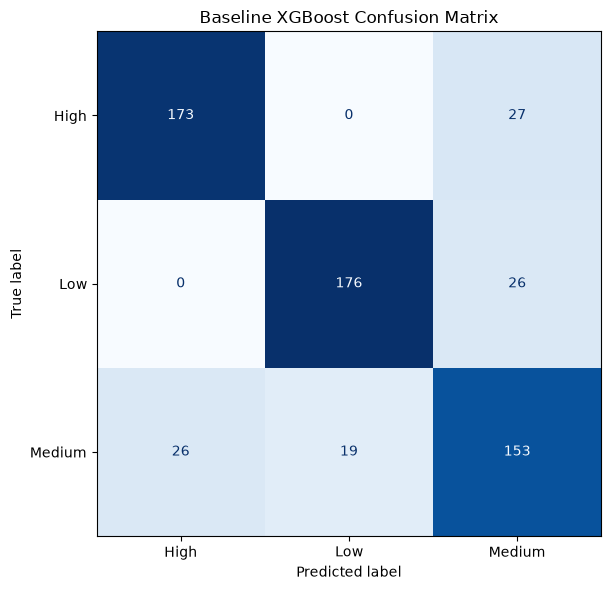

In [11]:
# Display the confusion matrix for the baseline XGBoost model

baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=["High", "Low", "Medium"]
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Baseline XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Define the hyperparameter values to be tested using GridSearchCV

parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [13]:
# Create the GridSearchCV object for XGBoost hyperparameter tuning

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss"
    ),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [14]:
# Perform hyperparameter tuning using GridSearchCV

start_time = time.time()

grid_search.fit(
    X_train,
    y_train_encoded
)

tuning_time = time.time() - start_time

print(f"GridSearchCV completed in {tuning_time:.2f} seconds.")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV completed in 58.21 seconds.


In [15]:
# Display the best hyperparameters identified by GridSearchCV

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best Cross Validation Score:
0.8711


In [16]:
# Retrieve the best XGBoost model from GridSearchCV

tuned_xgb = grid_search.best_estimator_

print("Tuned XGBoost model created successfully.")

Tuned XGBoost model created successfully.


In [17]:
# Generate predictions using the tuned XGBoost model

tuned_train_predictions = tuned_xgb.predict(
    X_train
)

tuned_test_predictions = tuned_xgb.predict(
    X_test
)

tuned_train_predictions = (
    pd.Series(tuned_train_predictions)
    .map(reverse_label_mapping)
)

tuned_test_predictions = (
    pd.Series(tuned_test_predictions)
    .map(reverse_label_mapping)
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
# Calculate the evaluation metrics for the tuned XGBoost model

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_generalisation_gap = (
    tuned_train_accuracy -
    tuned_test_accuracy
)

In [19]:
# Display the evaluation results of the tuned XGBoost model

print("=" * 50)
print("Tuned XGBoost Performance")
print("=" * 50)

print(f"Training Accuracy : {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy  : {tuned_test_accuracy:.4f}")
print(f"Precision         : {tuned_precision:.4f}")
print(f"Recall            : {tuned_recall:.4f}")
print(f"F1-Score          : {tuned_f1:.4f}")
print(f"Training Time (s) : {tuning_time:.4f}")
print(f"Generalisation Gap: {tuned_generalisation_gap:.4f}")

Tuned XGBoost Performance
Training Accuracy : 0.9800
Testing Accuracy  : 0.8400
Precision         : 0.8413
Recall            : 0.8400
F1-Score          : 0.8405
Training Time (s) : 58.2104
Generalisation Gap: 0.1400


In [20]:
# Display the classification report for the tuned XGBoost model

print("=" * 50)
print("Tuned XGBoost Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=4,
        zero_division=0
    )
)

Tuned XGBoost Classification Report
              precision    recall  f1-score   support

        High     0.8621    0.8750    0.8685       200
         Low     0.9077    0.8762    0.8917       202
      Medium     0.7525    0.7677    0.7600       198

    accuracy                         0.8400       600
   macro avg     0.8407    0.8396    0.8401       600
weighted avg     0.8413    0.8400    0.8405       600



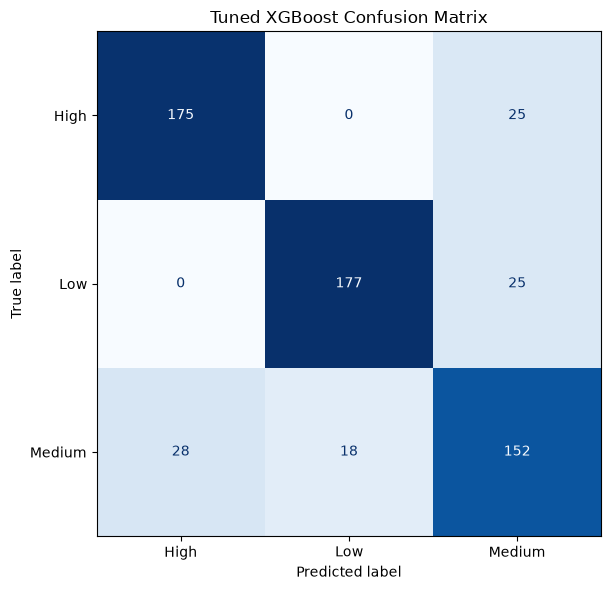

In [21]:
# Display the confusion matrix for the tuned XGBoost model

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=["High", "Low", "Medium"]
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Compare the baseline and tuned XGBoost models

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "Generalisation Gap": [
        generalisation_gap,
        tuned_generalisation_gap
    ]
})

comparison_results = comparison_results.round(4)

comparison_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline XGBoost,1.00,0.8367,0.8387,0.8367,0.8375,0.1633
1,Tuned XGBoost,0.98,0.8400,0.8413,0.8400,0.8405,0.1400


In [23]:
# Select the better XGBoost model based on the F1-Score

if tuned_f1 > f1:
    final_xgb_model = tuned_xgb
    selected_model = "Tuned XGBoost"
else:
    final_xgb_model = baseline_xgb
    selected_model = "Baseline XGBoost"

print("=" * 60)
print("Final XGBoost Model Selection")
print("=" * 60)

print(f"Selected Model : {selected_model}")

if selected_model == "Tuned XGBoost":
    print(f"Testing Accuracy : {tuned_test_accuracy:.4f}")
    print(f"F1-Score         : {tuned_f1:.4f}")
else:
    print(f"Testing Accuracy : {test_accuracy:.4f}")
    print(f"F1-Score         : {f1:.4f}")

print("\nReason:")
print("The selected model achieved better overall performance on the independent test dataset.")

Final XGBoost Model Selection
Selected Model : Tuned XGBoost
Testing Accuracy : 0.8400
F1-Score         : 0.8405

Reason:
The selected model achieved better overall performance on the independent test dataset.


In [24]:
# Save the baseline and tuned XGBoost models

joblib.dump(
    baseline_xgb,
    MODEL_PATH / "xgboost_baseline.pkl"
)

joblib.dump(
    tuned_xgb,
    MODEL_PATH / "xgboost_tuned.pkl"
)

print("XGBoost models saved successfully.")

XGBoost models saved successfully.


In [25]:
# Save the XGBoost comparison results

comparison_results.to_csv(
    RESULTS_PATH / "xgboost_results.csv",
    index=False
)

print("Comparison results saved successfully.")

Comparison results saved successfully.


In [26]:
# Save the GridSearchCV results

grid_search_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_results.to_csv(
    RESULTS_PATH / "xgboost_grid_search_results.csv",
    index=False
)

print("GridSearchCV results saved successfully.")

GridSearchCV results saved successfully.


In [27]:
# Save the best hyperparameters

joblib.dump(
    grid_search.best_params_,
    RESULTS_PATH / "xgboost_best_parameters.pkl"
)

print("Best hyperparameters saved successfully.")

Best hyperparameters saved successfully.


In [28]:
# Verify that all XGBoost files were saved successfully

files_to_check = [
    MODEL_PATH / "xgboost_baseline.pkl",
    MODEL_PATH / "xgboost_tuned.pkl",
    RESULTS_PATH / "xgboost_results.csv",
    RESULTS_PATH / "xgboost_grid_search_results.csv",
    RESULTS_PATH / "xgboost_best_parameters.pkl"
]

print("=" * 60)
print("Generated Files")
print("=" * 60)

for file in files_to_check:
    print(f"{file.name:<55} {file.exists()}")

Generated Files
xgboost_baseline.pkl                                    True
xgboost_tuned.pkl                                       True
xgboost_results.csv                                     True
xgboost_grid_search_results.csv                         True
xgboost_best_parameters.pkl                             True
